# 클로드코드를 이용한 머신러닝

이 노트북은 Claude Code를 활용하여 머신러닝 프로젝트를 진행하는 방법을 다룹니다.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# 한글 폰트 설정 (Windows)
import platform
from matplotlib import rc
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')

# 출력 형식 설정
np.set_printoptions(suppress=True, precision=4)
pd.options.display.float_format = '{:,.4f}'.format
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
plt.rcParams['font.size'] = 14

random_seed = 123

## 1단계: 데이터 로드 및 탐색

In [2]:
# 데이터 로드 (인코딩 자동 감지)
try:
    df = pd.read_csv('input/한국생명공학연구원_KCTC 미생물 자원 데이터_20240726.csv', encoding='utf-8')
except:
    df = pd.read_csv('input/한국생명공학연구원_KCTC 미생물 자원 데이터_20240726.csv', encoding='euc-kr')

print("=" * 70)
print("데이터 기본 정보")
print("=" * 70)
print(f"\n데이터 크기: {df.shape[0]} 행 × {df.shape[1]} 열")
print(f"\n컬럼명: {list(df.columns)}")
print(f"\n데이터 타입:")
print(df.dtypes)
print(f"\n첫 10개 행:")
print(df.head(10))
print(f"\n결측값 확인:")
print(df.isnull().sum())
print(f"\n분류별 샘플 분포:")
class_dist = df.iloc[:, -1].value_counts()
print(class_dist)
print(f"\n분포율:")
print(class_dist / len(df) * 100)

데이터 기본 정보

데이터 크기: 7505 행 × 3 열

컬럼명: ['자원번호', '자원명', '분류']

데이터 타입:
자원번호    int64
자원명       str
분류        str
dtype: object

첫 10개 행:
   자원번호                             자원명     분류
0  6968              Trichoderma reesei   Mold
1  7965                Candida albicans  Yeast
2  6983  Aspergillus oryzae var. oryzae   Mold
3  6048             Emericella nidulans   Mold
4  6052         Penicillium chrysogenum   Mold
5  6080         Penicillium roquefortii   Mold
6  7123              Ogataea polymorpha  Yeast
7  7125        Hanseniaspora valbyensis  Yeast
8  7134       Rhodosporidium toruloides  Yeast
9  7183        Zygosaccharomyces mrakii  Yeast

결측값 확인:
자원번호    0
자원명     0
분류      0
dtype: int64

분류별 샘플 분포:
분류
Bacteria    7391
Yeast         58
Archaea       43
Mold          13
Name: count, dtype: int64

분포율:
분류
Bacteria   98.4810
Yeast       0.7728
Archaea     0.5730
Mold        0.1732
Name: count, dtype: float64


## 2단계: 데이터 전처리 (텍스트 벡터화)

In [3]:
# Features와 Target 분리
# 미생물 학명(자원명)을 feature로 사용
X = df.iloc[:, 1]  # 두 번째 컬럼: 자원명 (텍스트)
y = df.iloc[:, 2]  # 세 번째 컬럼: 분류 (Bacteria, Mold, Yeast)

print("=" * 70)
print("피처 및 타겟 정보")
print("=" * 70)
print(f"\nFeatures (X) 샘플 5개:")
print(X.head())
print(f"\nTarget (y) 샘플 5개:")
print(y.head())
print(f"\nTarget 값 종류: {y.unique()}")

# TF-IDF 벡터화: 텍스트를 수치 데이터로 변환
# TF-IDF = 각 단어(또는 문자)의 중요도 점수화
vectorizer = TfidfVectorizer(
    analyzer='char',          # 문자 단위로 분석
    ngram_range=(2, 3),       # 2글자, 3글자 조합
    max_features=100,         # 상위 100개 features만 사용
    min_df=2,                 # 최소 2개 문서에서 나타나는 단어만
    max_df=0.8                # 80% 이상 문서에서 나타나는 단어는 제외
)

X_tfidf = vectorizer.fit_transform(X)

print(f"\n벡터화 완료!")
print(f"변환된 피처 크기: {X_tfidf.shape}")
print(f"사용된 피처 수: {len(vectorizer.get_feature_names_out())}")

피처 및 타겟 정보

Features (X) 샘플 5개:
0                Trichoderma reesei
1                  Candida albicans
2    Aspergillus oryzae var. oryzae
3               Emericella nidulans
4           Penicillium chrysogenum
Name: 자원명, dtype: str

Target (y) 샘플 5개:
0     Mold
1    Yeast
2     Mold
3     Mold
4     Mold
Name: 분류, dtype: str

Target 값 종류: <StringArray>
['Mold', 'Yeast', 'Bacteria', 'Archaea']
Length: 4, dtype: str

벡터화 완료!
변환된 피처 크기: (7505, 100)
사용된 피처 수: 100


## 3단계: 데이터 분할 (학습 70% / 검증 30%)

In [4]:
# 데이터 분할: 학습용(70%), 검증용(30%)
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, 
    test_size=0.3, 
    random_state=random_seed,
    stratify=y  # 각 클래스 비율 유지
)

print("=" * 70)
print("데이터 분할 결과")
print("=" * 70)
print(f"\n학습 데이터 크기: {X_train.shape[0]} (전체의 {X_train.shape[0]/len(y)*100:.1f}%)")
print(f"검증 데이터 크기: {X_test.shape[0]} (전체의 {X_test.shape[0]/len(y)*100:.1f}%)")
print(f"\n학습 데이터 클래스 분포:")
print(y_train.value_counts())
print(f"\n검증 데이터 클래스 분포:")
print(y_test.value_counts())

데이터 분할 결과

학습 데이터 크기: 5253 (전체의 70.0%)
검증 데이터 크기: 2252 (전체의 30.0%)

학습 데이터 클래스 분포:
분류
Bacteria    5173
Yeast         41
Archaea       30
Mold           9
Name: count, dtype: int64

검증 데이터 클래스 분포:
분류
Bacteria    2218
Yeast         17
Archaea       13
Mold           4
Name: count, dtype: int64


## 4단계: 모델 학습 (로지스틱 회귀 vs 결정트리)

In [5]:
print("=" * 70)
print("모델 학습 시작")
print("=" * 70)

# ===== 모델 1: 로지스틱 회귀 =====
print("\n[1] 로지스틱 회귀(Logistic Regression) 학습 중...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=random_seed
)
lr_model.fit(X_train, y_train)
print("OK 로지스틱 회귀 학습 완료!")

# ===== 모델 2: 결정트리 =====
print("\n[2] 결정트리(Decision Tree) 학습 중...")
dt_model = DecisionTreeClassifier(
    max_depth=15,           # 트리 깊이 제한 (과적합 방지)
    min_samples_split=20,   # 노드 분할 최소 샘플 수
    min_samples_leaf=10,    # 리프 노드 최소 샘플 수
    random_state=random_seed
)
dt_model.fit(X_train, y_train)
print("OK 결정트리 학습 완료!")

print("\n학습 완료! 이제 검증 데이터로 평가합니다...")

모델 학습 시작

[1] 로지스틱 회귀(Logistic Regression) 학습 중...
OK 로지스틱 회귀 학습 완료!

[2] 결정트리(Decision Tree) 학습 중...
OK 결정트리 학습 완료!

학습 완료! 이제 검증 데이터로 평가합니다...


## 5단계: 모델 평가 및 성능 비교

In [6]:
# 예측 수행
y_pred_lr = lr_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

# 평가 함수
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{'=' * 70}")
    print(f"[{model_name}] 성능 평가")
    print(f"{'=' * 70}")
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print(f"\n기본 성능 지표:")
    print(f"  * Accuracy  (정확도):   {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  * Precision (정밀도):   {precision:.4f}")
    print(f"  * Recall    (재현율):   {recall:.4f}")
    print(f"  * F1-Score:             {f1:.4f}")
    
    print(f"\n클래스별 성능:")
    print(classification_report(y_true, y_pred, digits=4))
    
    print(f"\n혼동 행렬 (Confusion Matrix):")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    
    return accuracy, precision, recall, f1, cm

# 두 모델 평가
lr_results = evaluate_model(y_test, y_pred_lr, "로지스틱 회귀")
dt_results = evaluate_model(y_test, y_pred_dt, "결정트리")


[로지스틱 회귀] 성능 평가

기본 성능 지표:
  * Accuracy  (정확도):   0.9849 (98.49%)
  * Precision (정밀도):   0.9700
  * Recall    (재현율):   0.9849
  * F1-Score:             0.9774

클래스별 성능:
              precision    recall  f1-score   support

     Archaea     0.0000    0.0000    0.0000        13
    Bacteria     0.9849    1.0000    0.9924      2218
        Mold     0.0000    0.0000    0.0000         4
       Yeast     0.0000    0.0000    0.0000        17

    accuracy                         0.9849      2252
   macro avg     0.2462    0.2500    0.2481      2252
weighted avg     0.9700    0.9849    0.9774      2252


혼동 행렬 (Confusion Matrix):
[[   0   13    0    0]
 [   0 2218    0    0]
 [   0    4    0    0]
 [   0   17    0    0]]

[결정트리] 성능 평가

기본 성능 지표:
  * Accuracy  (정확도):   0.9840 (98.40%)
  * Precision (정밀도):   0.9719
  * Recall    (재현율):   0.9840
  * F1-Score:             0.9776

클래스별 성능:
              precision    recall  f1-score   support

     Archaea     0.2500    0.0769    0.1176        13

## 6단계: 성능 비교 시각화

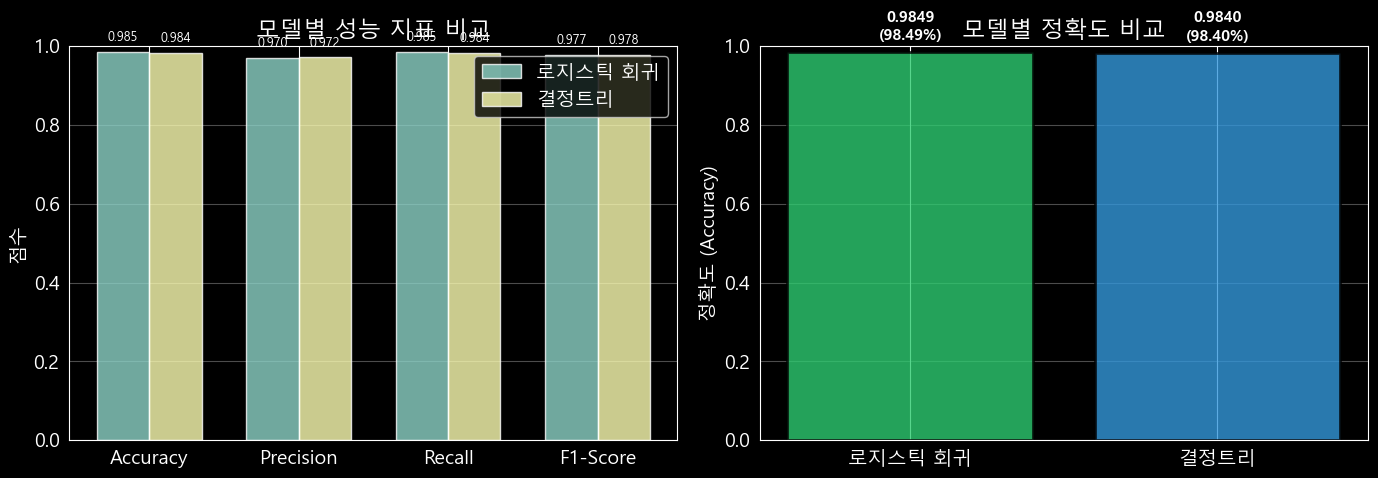


OK 그래프 저장 완료: output/model_comparison.png


In [7]:
# 성능 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 성능 지표 비교 (막대 그래프)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_scores = [lr_results[0], lr_results[1], lr_results[2], lr_results[3]]
dt_scores = [dt_results[0], dt_results[1], dt_results[2], dt_results[3]]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, lr_scores, width, label='로지스틱 회귀', alpha=0.8)
axes[0].bar(x + width/2, dt_scores, width, label='결정트리', alpha=0.8)
axes[0].set_ylabel('점수')
axes[0].set_title('모델별 성능 지표 비교')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# 각 막대 위에 값 표시
for i, (lr, dt) in enumerate(zip(lr_scores, dt_scores)):
    axes[0].text(i - width/2, lr + 0.02, f'{lr:.3f}', ha='center', va='bottom', fontsize=9)
    axes[0].text(i + width/2, dt + 0.02, f'{dt:.3f}', ha='center', va='bottom', fontsize=9)

# 2. Accuracy 비교 (간단한 비교)
models = ['로지스틱 회귀', '결정트리']
accuracies = [lr_results[0], dt_results[0]]
colors = ['#2ecc71', '#3498db']

bars = axes[1].bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[1].set_ylabel('정확도 (Accuracy)')
axes[1].set_title('모델별 정확도 비교')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

# 값 표시
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{acc:.4f}\n({acc*100:.2f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('output/model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nOK 그래프 저장 완료: output/model_comparison.png")

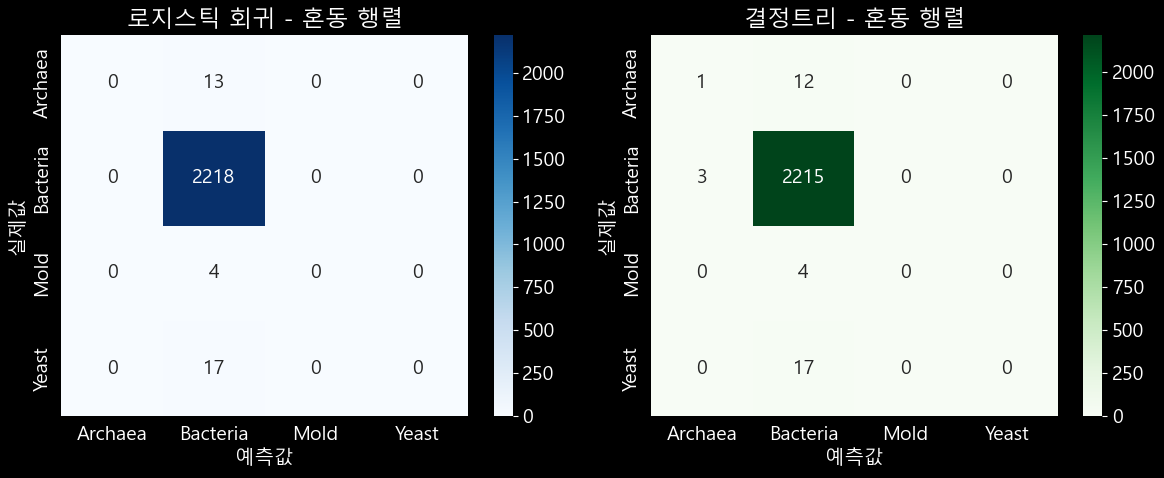


OK 혼동 행렬 저장 완료: output/confusion_matrices.png


In [8]:
# 혼동 행렬 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 클래스명
classes = sorted(y.unique())

# 로지스틱 회귀 혼동 행렬
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=classes)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes, ax=axes[0], cbar=True)
axes[0].set_title('로지스틱 회귀 - 혼동 행렬')
axes[0].set_ylabel('실제값')
axes[0].set_xlabel('예측값')

# 결정트리 혼동 행렬
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=classes)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes, ax=axes[1], cbar=True)
axes[1].set_title('결정트리 - 혼동 행렬')
axes[1].set_ylabel('실제값')
axes[1].set_xlabel('예측값')

plt.tight_layout()
plt.savefig('output/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nOK 혼동 행렬 저장 완료: output/confusion_matrices.png")

## 7단계: 결론 및 개선 방안

In [9]:
print("=" * 80)
print("모델 성능 비교 분석")
print("=" * 80)

# 성능 차이 계산
lr_acc = lr_results[0]
dt_acc = dt_results[0]
diff = abs(lr_acc - dt_acc)
winner = "로지스틱 회귀" if lr_acc > dt_acc else "결정트리"

print(f"\n[성능 비교]")
print(f"  * 로지스틱 회귀 Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)")
print(f"  * 결정트리 Accuracy:      {dt_acc:.4f} ({dt_acc*100:.2f}%)")
print(f"  * 성능 차이:              {diff:.4f} ({diff*100:.2f}%)")
print(f"\n  => 우승: {winner}")

print(f"\n{'=' * 80}")
print(f"모델별 특징 분석")
print(f"{'=' * 80}")

print(f"""
[로지스틱 회귀 (Logistic Regression)]
  * 장점:
    - 선형 관계를 잘 포착
    - 학습 속도가 빠름
    - 확률 해석이 직관적 (0~1 사이)
  * 단점:
    - 비선형 관계 학습 어려움
    - 텍스트 데이터에서는 성능 제한적

[결정트리 (Decision Tree)]
  * 장점:
    - 텍스트의 패턴을 더 잘 포착
    - 특정 문자열 패턴에 집중 가능
    - 과적합 방지 파라미터 조절 가능
  * 단점:
    - 깊이가 깊으면 과적합 위험
    - 학습 시간이 더 오래 걸림
""")

print(f"{'=' * 80}")
print(f"개선 방안")
print(f"{'=' * 80}")

print(f"""
[우선순위 1] 데이터 불균형 해결 (매우 중요)
  * class_weight='balanced' 추가
  * SMOTE 오버샘플링

[우선순위 2] 평가 지표 변경
  * Accuracy -> Macro-F1 Score
  * 모든 클래스를 균등하게 평가

[우선순위 3] 모델 개선
  * Random Forest (앙상블)
  * Gradient Boosting (XGBoost)
  * SVM (Support Vector Machine)

[우선순위 4] 피처 엔지니어링
  * TF-IDF 파라미터 최적화
  * max_features: 100 -> 200, 300
  * ngram_range: (2,3) -> (1,3)

[우선순위 5] 하이퍼파라미터 튜닝
  * GridSearchCV 사용
  * 자동 최적화

[다음 단계]
① class_weight='balanced' 추가
② Random Forest 시도
③ Macro-F1으로 평가
④ 신경망(딥러닝) 시도 - 컴비젼5 과정
""")

모델 성능 비교 분석

[성능 비교]
  * 로지스틱 회귀 Accuracy: 0.9849 (98.49%)
  * 결정트리 Accuracy:      0.9840 (98.40%)
  * 성능 차이:              0.0009 (0.09%)

  => 우승: 로지스틱 회귀

모델별 특징 분석

[로지스틱 회귀 (Logistic Regression)]
  * 장점:
    - 선형 관계를 잘 포착
    - 학습 속도가 빠름
    - 확률 해석이 직관적 (0~1 사이)
  * 단점:
    - 비선형 관계 학습 어려움
    - 텍스트 데이터에서는 성능 제한적

[결정트리 (Decision Tree)]
  * 장점:
    - 텍스트의 패턴을 더 잘 포착
    - 특정 문자열 패턴에 집중 가능
    - 과적합 방지 파라미터 조절 가능
  * 단점:
    - 깊이가 깊으면 과적합 위험
    - 학습 시간이 더 오래 걸림

개선 방안

[우선순위 1] 데이터 불균형 해결 (매우 중요)
  * class_weight='balanced' 추가
  * SMOTE 오버샘플링

[우선순위 2] 평가 지표 변경
  * Accuracy -> Macro-F1 Score
  * 모든 클래스를 균등하게 평가

[우선순위 3] 모델 개선
  * Random Forest (앙상블)
  * Gradient Boosting (XGBoost)
  * SVM (Support Vector Machine)

[우선순위 4] 피처 엔지니어링
  * TF-IDF 파라미터 최적화
  * max_features: 100 -> 200, 300
  * ngram_range: (2,3) -> (1,3)

[우선순위 5] 하이퍼파라미터 튜닝
  * GridSearchCV 사용
  * 자동 최적화

[다음 단계]
① class_weight='balanced' 추가
② Random Forest 시도
③ Macro-F1으로 평가
④ 신경망(딥러닝) 시도 - 컴비젼5 과정

